# Hotel Booking Cancellation Prediction

## Final Internship Machine Learning Project

### Project Overview

Hotel cancellations can lead to revenue loss and make it difficult for hotels to manage room availability and operational resources.

This project develops a Machine Learning classification system that predicts whether a hotel booking will be cancelled.

The project uses the Hotel Booking Demand dataset, which contains booking information for City Hotels and Resort Hotels.

### Business Objective

The main objective is to identify bookings that are likely to be cancelled before the customer's arrival.

A reliable prediction model can help hotels:

- Identify high-risk bookings.
- Improve reservation management.
- Develop appropriate cancellation and deposit strategies.
- Reduce potential revenue loss.
- Improve room occupancy planning.

### Machine Learning Objective

The target variable is:

- `is_canceled = 0` → Booking was not cancelled.
- `is_canceled = 1` → Booking was cancelled.

The project will follow a complete Machine Learning pipeline including:

- Dataset Understanding
- Data Cleaning and Preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Data Leakage Prevention
- Feature Selection
- Encoding and Scaling
- Class Imbalance Handling
- Multiple Machine Learning Models
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance
- Business Impact Analysis
- Business Recommendations

# 1. Import Libraries

The following libraries are used for data manipulation, visualization, preprocessing, Machine Learning, model evaluation and hyperparameter tuning.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

# Visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## Library Explanation

- **Pandas** is used for loading, cleaning and manipulating the dataset.
- **NumPy** is used for numerical operations.
- **Matplotlib** and **Seaborn** are used to create visualizations for EDA and model evaluation.
- **Scikit-learn** provides preprocessing tools, Machine Learning algorithms, model selection and evaluation metrics.
- **StandardScaler** standardizes numerical features so that variables with different scales can be compared appropriately.
- **OneHotEncoder** converts categorical variables into numerical indicator columns.
- **Pipeline** allows preprocessing and model training to be performed consistently.
- **GridSearchCV** will be used later to tune model hyperparameters.

# 2. Helper Functions

We will use helper functions to organize repetitive operations and make the notebook easier to read and maintain.

In [2]:
def dataset_overview(data):
    
    print("=" * 70)
    print("DATASET SHAPE")
    print("=" * 70)
    print(data.shape)
    
    print("\n" + "=" * 70)
    print("DATA TYPES")
    print("=" * 70)
    print(data.dtypes)
    
    print("\n" + "=" * 70)
    print("MISSING VALUES")
    print("=" * 70)
    print(data.isnull().sum())
    
    print("\n" + "=" * 70)
    print("DUPLICATE RECORDS")
    print("=" * 70)
    print(data.duplicated().sum())

In [3]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }
    
    return results

# 3. Load Dataset

The Hotel Booking Demand dataset is loaded into a Pandas DataFrame.

The dataset contains booking records for City Hotels and Resort Hotels and includes information about booking timing, customer characteristics, stay details, room information, distribution channels and cancellation status.

In [4]:
file_path = "hotel_bookings.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.0,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


### Initial Observation

Each row represents one hotel booking.

The dataset contains information about:

- Hotel type
- Booking timing
- Arrival date
- Length of stay
- Number of guests
- Meal preferences
- Customer origin
- Market segment
- Previous booking history
- Room type
- Deposit type
- Customer type
- Special requests
- Cancellation status

# 4. Dataset Understanding

Before cleaning or modeling the data, it is important to understand its structure, feature types, data quality and target variable.

This helps us identify potential preprocessing requirements and possible sources of data leakage.

In [7]:
dataset_overview(df)

DATASET SHAPE
(119390, 32)

DATA TYPES
hotel                           object
is_canceled                      int64
lead_time                        int64
arrival_date_year                int64
arrival_date_month              object
                                ...   
adr                            float64
required_car_parking_spaces      int64
total_of_special_requests        int64
reservation_status              object
reservation_status_date         object
Length: 32, dtype: object

MISSING VALUES
hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_year              0
arrival_date_month             0
                              ..
adr                            0
required_car_parking_spaces    0
total_of_special_requests      0
reservation_status             0
reservation_status_date        0
Length: 32, dtype: int64

DUPLICATE RECORDS
31994


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
adr,119390.0,NaN,NaN,NaN,101.831122,50.53579,-6.38,69.29,94.575,126.0,5400.0
required_car_parking_spaces,119390.0,NaN,NaN,NaN,0.062518,0.245291,0.0,0.0,0.0,0.0,8.0
total_of_special_requests,119390.0,NaN,NaN,NaN,0.571363,0.792798,0.0,0.0,0.0,1.0,5.0
reservation_status,119390,3,Check-Out,75166,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature Description

| Feature | Description |
|---|---|
| `hotel` | Type of hotel: Resort Hotel or City Hotel |
| `is_canceled` | Target: whether the booking was cancelled |
| `lead_time` | Number of days between booking and arrival |
| `arrival_date_year` | Arrival year |
| `arrival_date_month` | Arrival month |
| `arrival_date_week_number` | Arrival week number |
| `arrival_date_day_of_month` | Arrival day |
| `stays_in_weekend_nights` | Weekend nights booked |
| `stays_in_week_nights` | Weekday nights booked |
| `adults` | Number of adults |
| `children` | Number of children |
| `babies` | Number of babies |
| `meal` | Meal plan booked |
| `country` | Country of origin |
| `market_segment` | Market segment through which booking was made |
| `distribution_channel` | Distribution channel used |
| `is_repeated_guest` | Whether the customer is a repeated guest |
| `previous_cancellations` | Number of previous cancelled bookings |
| `previous_bookings_not_canceled` | Number of previous bookings that were not cancelled |
| `reserved_room_type` | Room type originally reserved |
| `assigned_room_type` | Room type actually assigned |
| `booking_changes` | Number of changes made to the booking |
| `deposit_type` | Deposit type |
| `agent` | Booking agent identifier |
| `company` | Company identifier |
| `days_in_waiting_list` | Number of days the booking was on the waiting list |
| `customer_type` | Type of customer |
| `adr` | Average Daily Rate |
| `required_car_parking_spaces` | Number of parking spaces requested |
| `total_of_special_requests` | Number of special requests |
| `reservation_status` | Final reservation status |
| `reservation_status_date` | Date associated with the final reservation status |

## Data Leakage Consideration

Data leakage occurs when information that would not be available at prediction time is provided to the Machine Learning model.

For this project, the goal is to predict cancellation risk using information available when the booking is being analyzed.

Therefore, variables that directly reveal the final outcome must not be used as predictors.

In particular:

- `reservation_status` records the final reservation outcome.
- `reservation_status_date` is associated with the final reservation outcome.

Using these variables could allow the model to indirectly know whether the booking was cancelled.

Therefore, these features will be removed before model training.

This ensures that the model learns genuine booking patterns rather than information revealed after the booking outcome.

In [10]:
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_columns)

print("Leakage-prone columns removed successfully.")

Leakage-prone columns removed successfully.


In [11]:
df.shape

(119390, 30)

### Why are we doing this?

Our model should answer:

> "Based on what we know about a booking, how likely is it to be cancelled?"

It should NOT answer:

> "Given that we already know the booking's final status, was it cancelled?"

Removing these variables makes the prediction task realistic and prevents artificially inflated model performance.

# 5. Data Cleaning & Preprocessing

Real-world hotel booking data may contain missing values, duplicate bookings,
inconsistent records, and variables that require careful interpretation.

In this section, we will inspect and clean the dataset while preserving useful
information wherever possible.

The main steps are:

- Checking missing values
- Checking duplicate records
- Checking data types
- Handling missing values appropriately
- Identifying invalid booking records
- Reviewing potentially problematic features
- Performing a final data quality check

In [12]:
df_clean = df.copy()
print("Backup dataset created successfully.")
print("Original shape:", df.shape)

Backup dataset created successfully.
Original shape: (119390, 30)


## 5.1 Missing Value Analysis

Missing values are common in real-world datasets.

Instead of immediately deleting rows containing missing values, we first determine
which columns contain missing values and understand why those values may be missing.

In [13]:
missing_values = df_clean.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns containing missing values:")
display(missing_values)

Columns containing missing values:


company     112593
agent        16340
country        488
children         4
dtype: int64

In [14]:
missing_percentage = (
    df_clean.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage = missing_percentage[missing_percentage > 0]
display(missing_percentage)

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64

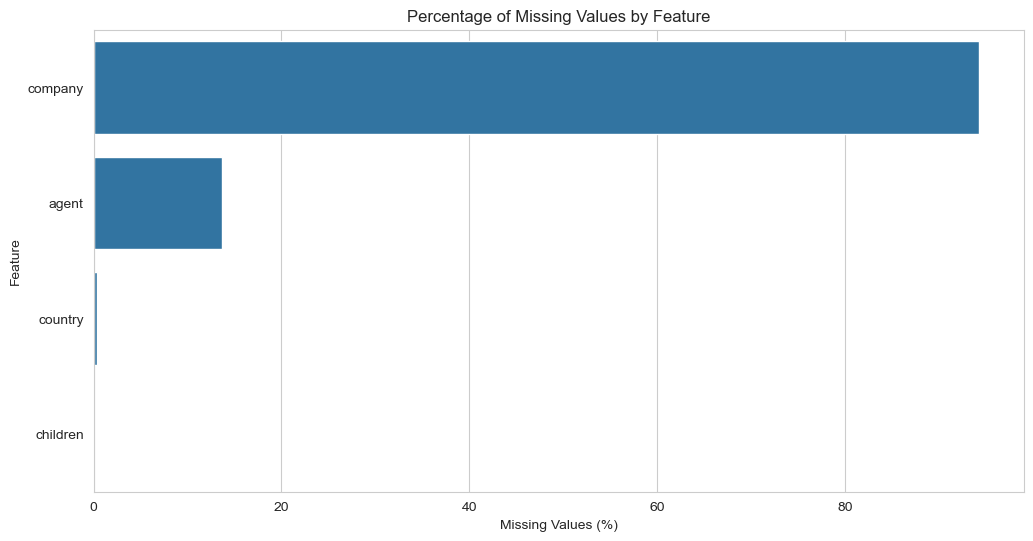

In [15]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.show()

### Observation

The missing-value analysis shows that missingness is concentrated in a small number
of features, particularly `company`, `agent`, `country`, and `children`.

These features will be handled according to their meaning rather than applying
the same treatment to every column.

In [16]:
print("Missing children values:", df_clean["children"].isnull().sum())

print("\nChildren distribution:")
display(df_clean["children"].value_counts(dropna=False).sort_index())

Missing children values: 4

Children distribution:


children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
NaN          4
Name: count, dtype: int64

In [17]:
print("Median number of children:", df_clean["children"].median())

Median number of children: 0.0


In [18]:
df_clean["children"] = df_clean["children"].fillna(
    df_clean["children"].median()
)

### Why Median Imputation?

`children` is numerical and contains only a small number of missing values.

The median is used because it is less affected by unusually large family sizes
than the mean.

This allows us to retain otherwise valid booking records.

In [19]:
print("Missing country values:", df_clean["country"].isnull().sum())

Missing country values: 488


In [20]:
df_clean["country"] = df_clean["country"].fillna("Unknown")

### Why Use "Unknown"?

A missing country does not mean that the booking itself is invalid.

Replacing missing values with `"Unknown"` preserves the booking while explicitly
representing the fact that the guest's country was unavailable.

This is preferable to deleting potentially useful booking records.

In [21]:
print("Missing agent values:", df_clean["agent"].isnull().sum())
print("Missing company values:", df_clean["company"].isnull().sum())

Missing agent values: 16340
Missing company values: 112593


In [22]:
df_clean["agent"] = df_clean["agent"].fillna(0)
df_clean["company"] = df_clean["company"].fillna(0)

### Interpretation of Agent and Company

`agent` and `company` represent identifiers rather than continuous numerical
measurements.

A missing value can indicate that no agent or company was associated with the
booking. Therefore, missing values are represented using `0` rather than
deleting the booking.

In [23]:
print("Remaining missing values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Remaining missing values:


Series([], dtype: int64)

## 5.2 Duplicate Records

Exact duplicate records do not provide additional information about different
bookings. Keeping them could give duplicated observations greater influence
during analysis and model training.

We therefore identify and remove exact duplicate records.

In [24]:
duplicate_count = df_clean.duplicated().sum()
print("Duplicate records:", duplicate_count)

Duplicate records: 32252


In [25]:
df_clean.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (87138, 30)


In [26]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87138 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87138 non-null  object 
 1   is_canceled                     87138 non-null  int64  
 2   lead_time                       87138 non-null  int64  
 3   arrival_date_year               87138 non-null  int64  
 4   arrival_date_month              87138 non-null  object 
 5   arrival_date_week_number        87138 non-null  int64  
 6   arrival_date_day_of_month       87138 non-null  int64  
 7   stays_in_weekend_nights         87138 non-null  int64  
 8   stays_in_week_nights            87138 non-null  int64  
 9   adults                          87138 non-null  int64  
 10  children                        87138 non-null  float64
 11  babies                          87138 non-null  int64  
 12  meal                            8713

## 5.3 Data Type Validation

Correct data types are important because Machine Learning algorithms require
numerical features to be represented numerically, while categorical variables
must later be encoded.

We therefore inspect the data types before continuing with feature engineering.

In [27]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,87138.0,0.272751,0.445377,0.00,0.0,0.0,1.0,1.0
lead_time,87138.0,79.720122,85.944218,0.00,11.0,49.0,125.0,737.0
arrival_date_year,87138.0,2016.210528,0.686004,2015.00,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,87138.0,26.836363,13.674634,1.00,16.0,27.0,37.0,53.0
arrival_date_day_of_month,87138.0,15.814409,8.835157,1.00,8.0,16.0,23.0,31.0
stays_in_weekend_nights,87138.0,1.005245,1.031531,0.00,0.0,1.0,2.0,19.0
stays_in_week_nights,87138.0,2.625353,2.051628,0.00,1.0,2.0,4.0,50.0
adults,87138.0,1.875841,0.626795,0.00,2.0,2.0,2.0,55.0
children,87138.0,0.138849,0.456203,0.00,0.0,0.0,0.0,10.0
babies,87138.0,0.010856,0.113763,0.00,0.0,0.0,0.0,10.0


In [28]:
zero_guest_bookings = df_clean[
    (df_clean["adults"] == 0) &
    (df_clean["children"] == 0) &
    (df_clean["babies"] == 0)
]
print("Bookings with zero guests:", len(zero_guest_bookings))

Bookings with zero guests: 166


## 5.4 Invalid Guest Records

A booking with zero adults, zero children and zero babies does not represent
a valid guest stay, thus they should be removed.

In [29]:
display(zero_guest_bookings.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,0.0,174.0,0,Transient-Party,0.0,0,0
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.0,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,0.0,174.0,0,Transient,0.0,0,0
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.0,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.0,0.0,0,Transient-Party,0.0,0,0
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.0,0.0,122,Transient-Party,0.0,0,0
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.0,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.0,0.0,122,Transient-Party,0.0,0,0


In [30]:
df_clean = df_clean[
    ~(
        (df_clean["adults"] == 0) &
        (df_clean["children"] == 0) &
        (df_clean["babies"] == 0)
    )
]

In [31]:
numeric_checks = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

for column in numeric_checks:
    negative_count = (df_clean[column] < 0).sum()
    
    if negative_count > 0:
        print(column, ":", negative_count, "negative values")

adr : 1 negative values


In [32]:
df_clean[df_clean["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0.0,0,Transient-Party,-6.38,0,0


In [33]:
df_clean = df_clean[df_clean["adr"] >= 0]
print("Negative ADR values remaining:", (df_clean["adr"] < 0).sum())

Negative ADR values remaining: 0


In [34]:
categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].unique())


hotel
['Resort Hotel' 'City Hotel']

arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']

meal
['BB' 'FB' 'HB' 'SC' 'Undefined']

country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' 'Unknown' 'ROU' 'NOR' 'OMN' 'ARG'
 'POL' 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS'
 'EST' 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX'
 'MAR' 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF'
 'AGO' 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN'
 'JAM' 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL'
 'GGY' 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL'
 'SEN' 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA'
 'CUB' 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'JOR' 'SYR' 'SGP'
 'BDI' 'SAU' 'VNM' 'PLW' 'QAT' 'EGY' 'PER' 'MLT' 'MWI' 'ECU' 'MDG' 'ISL'
 'UZB' 'NPL' 'BHS' 'MAC' 'TGO' 'TWN' 'DJI' 'STP' 'KNA'

In [35]:
print(df_clean["is_canceled"].value_counts())

print("\nPercentage:")
print(
    df_clean["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
)

is_canceled
0    63220
1    23751
Name: count, dtype: int64

Percentage:
is_canceled
0    72.690897
1    27.309103
Name: proportion, dtype: float64


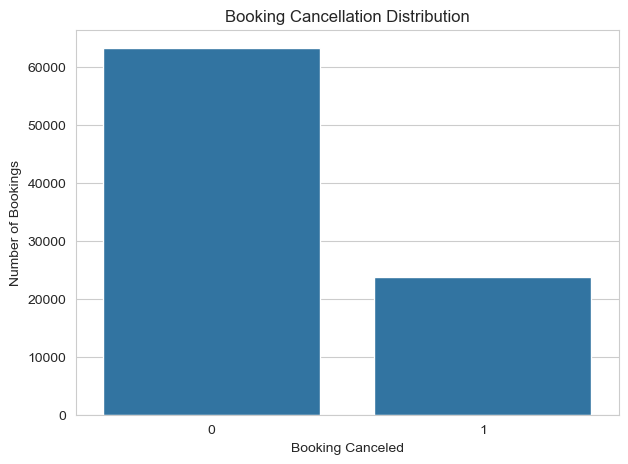

In [36]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_clean,
    x="is_canceled"
)

plt.title("Booking Cancellation Distribution")
plt.xlabel("Booking Canceled")
plt.ylabel("Number of Bookings")
plt.show()

### Target Variable

The target variable `is_canceled` indicates whether a hotel booking was canceled.

- `0` represents a booking that was not canceled.
- `1` represents a canceled booking.

The distribution will be examined further during EDA because class imbalance can
affect Machine Learning performance.

In [37]:
print("Original dataset shape :", df.shape)
print("Cleaned dataset shape  :", df_clean.shape)

rows_removed = df.shape[0] - df_clean.shape[0]

print("Rows removed:", rows_removed)

Original dataset shape : (119390, 30)
Cleaned dataset shape  : (86971, 30)
Rows removed: 32419


## Cleaning Summary

The dataset has now been cleaned while preserving as much valid information as
possible.

The preprocessing included:

- Missing-value analysis
- Appropriate treatment of missing values
- Duplicate removal
- Data-type validation
- Invalid guest-record detection
- Numerical consistency checks
- Categorical consistency inspection
- Target-variable inspection
- Data-leakage prevention

The cleaned dataset will now be used for detailed Exploratory Data Analysis.

# 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure,
patterns, relationships and distributions within the cleaned dataset.

The analysis focuses on identifying factors associated with hotel booking
cancellations and generating insights that can guide later feature engineering
and Machine Learning.

The analysis includes:

- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Target variable analysis
- Numerical and categorical feature analysis
- Outlier detection
- Correlation analysis

## Numerical Feature Distributions

Univariate analysis examines one variable at a time.

We use histograms to understand the distribution of numerical variables and
identify skewness or unusual patterns.

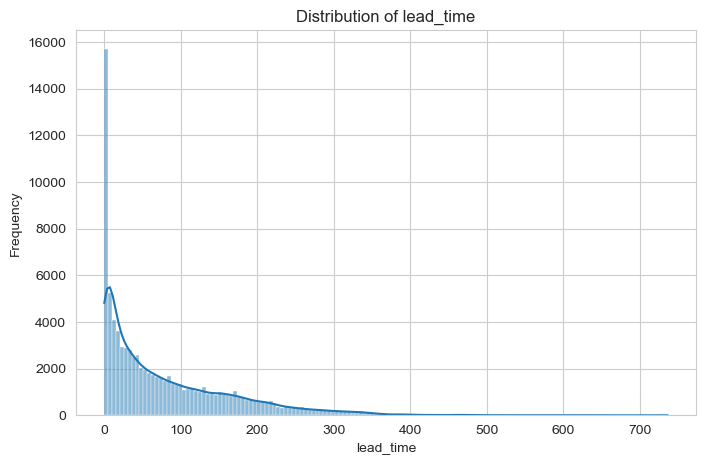

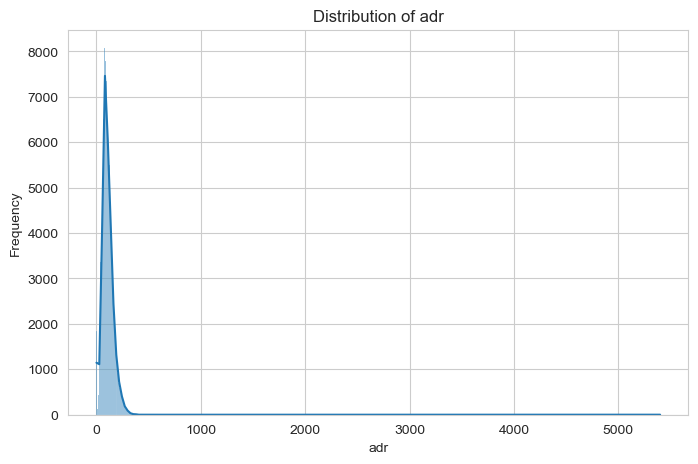

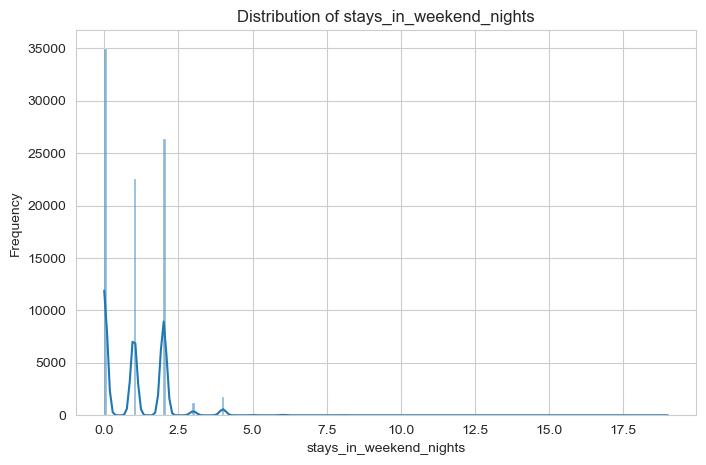

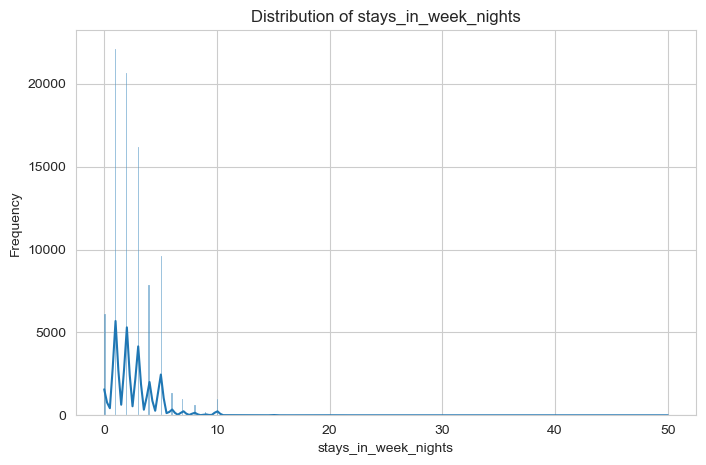

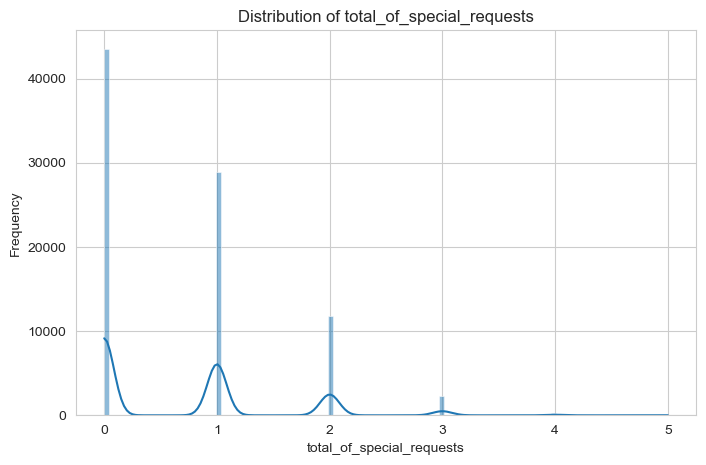

In [38]:
numerical_features = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_of_special_requests"
]

for column in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df_clean,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

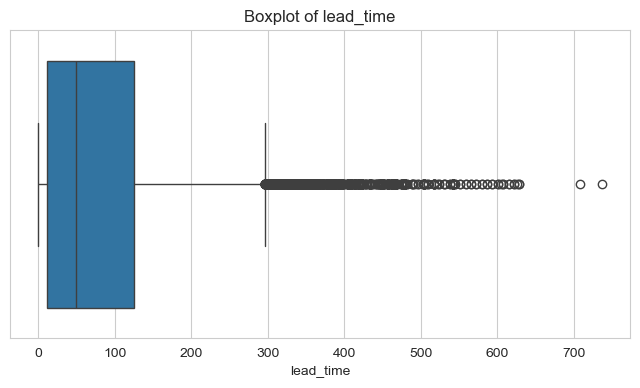

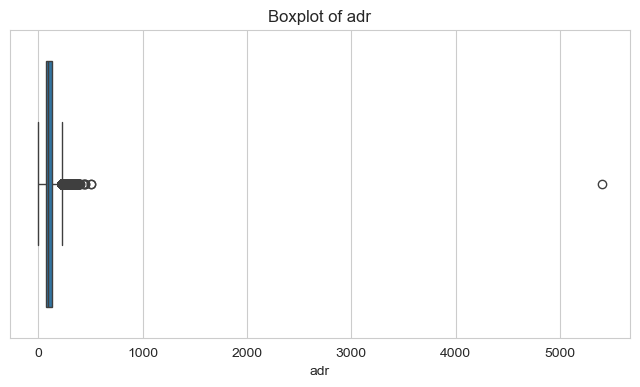

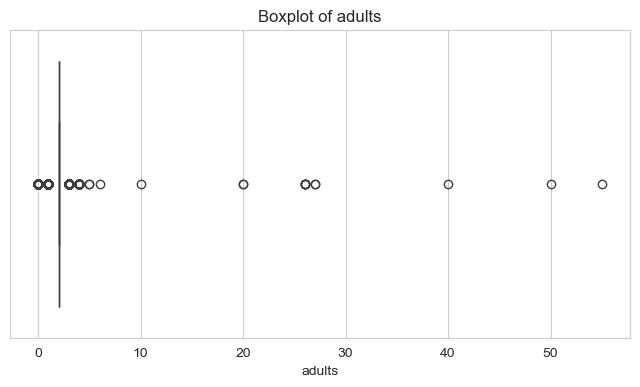

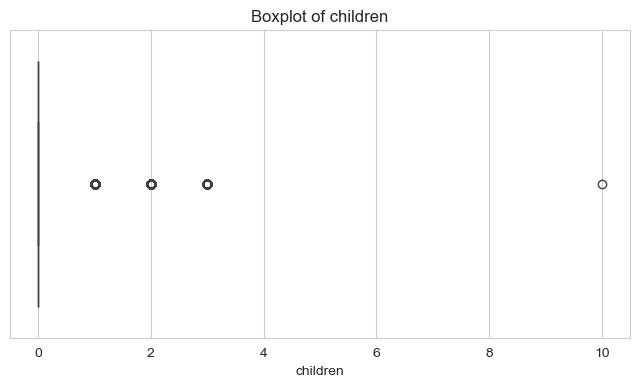

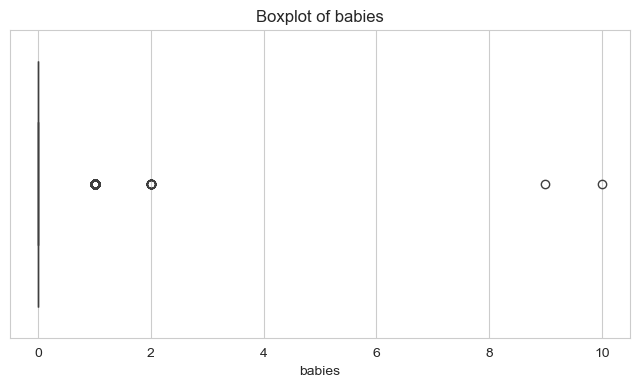

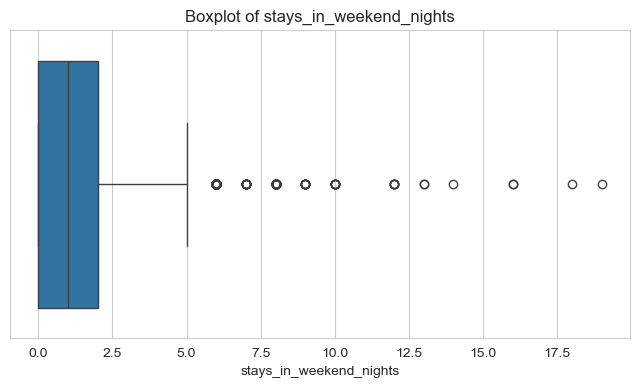

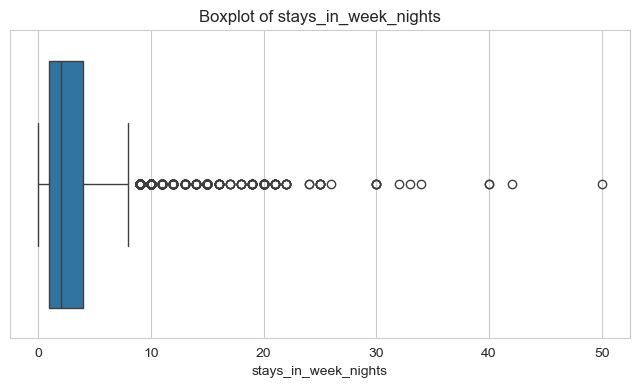

In [39]:
outlier_features = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]

for column in outlier_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        x=df_clean[column]
    )
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

### Outlier Interpretation

Boxplots are used to identify unusually high or low observations.

Outliers will not automatically be removed because unusual values may represent
legitimate hotel behavior, such as large group bookings or expensive rooms.

They will instead be interpreted based on their business meaning.

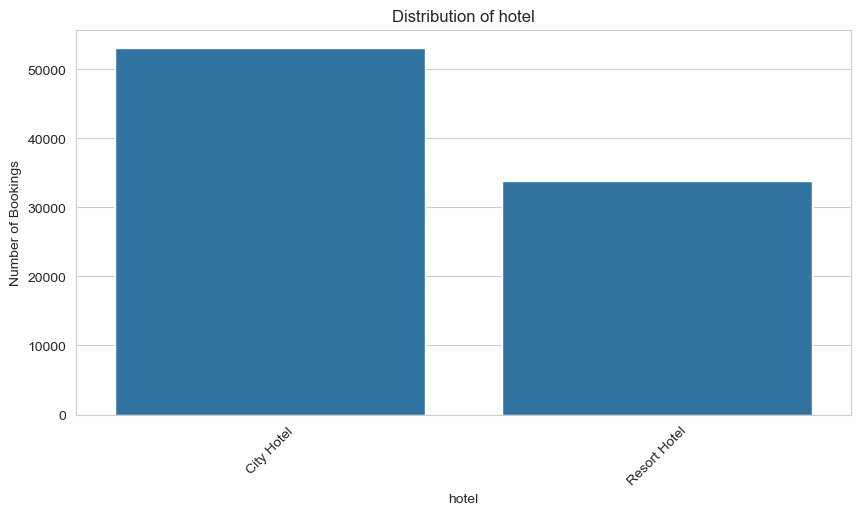

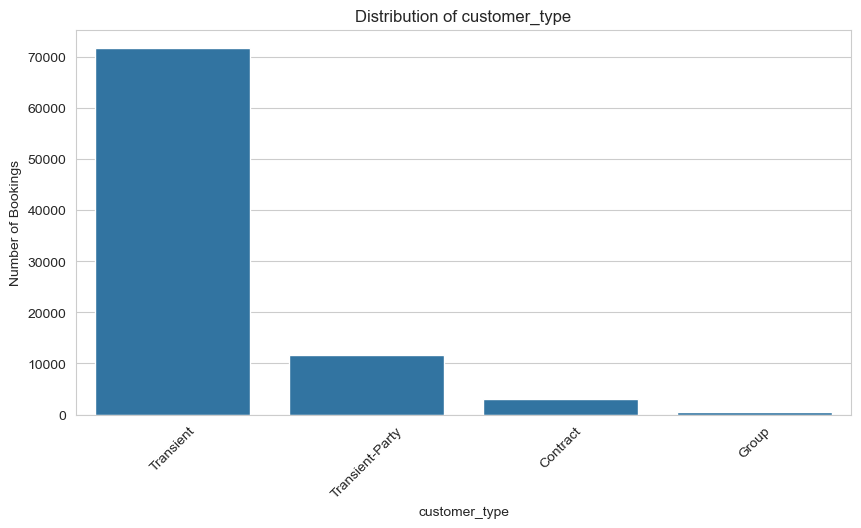

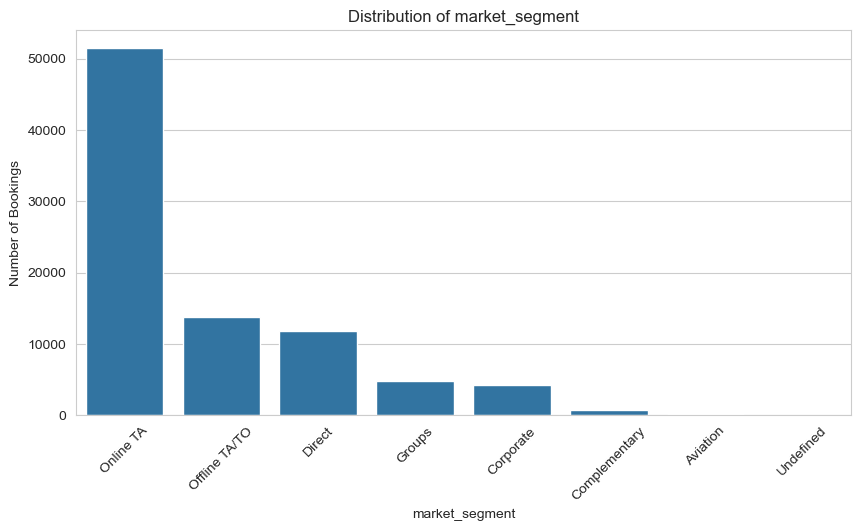

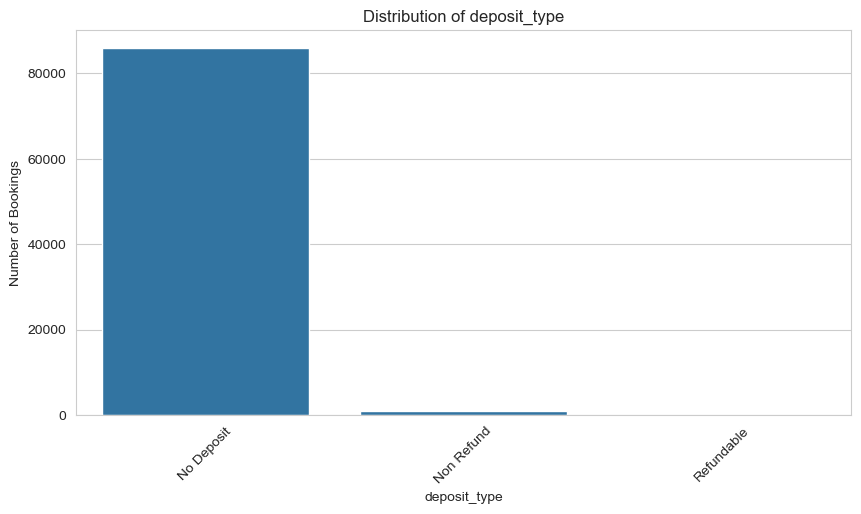

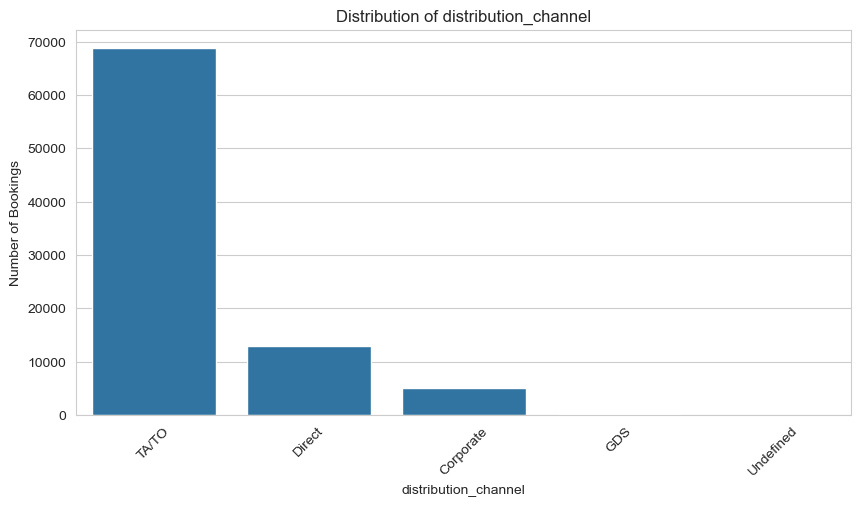

In [40]:
categorical_features = [
    "hotel",
    "customer_type",
    "market_segment",
    "deposit_type",
    "distribution_channel"
]

for column in categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df_clean,
        x=column,
        order=df_clean[column].value_counts().index
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Bookings")
    plt.xticks(rotation=45)
    plt.show()

### Interpretation

These visualizations show how frequently different categories occur in the
dataset.

Understanding category frequencies is important because some categories may
represent substantially more bookings than others.

In [41]:
hotel_cancellation = pd.crosstab(
    df_clean["hotel"],
    df_clean["is_canceled"],
    normalize="index"
) * 100

display(hotel_cancellation)

is_canceled,0,1
hotel,,
City Hotel,70.131264,29.868736
Resort Hotel,76.703472,23.296528


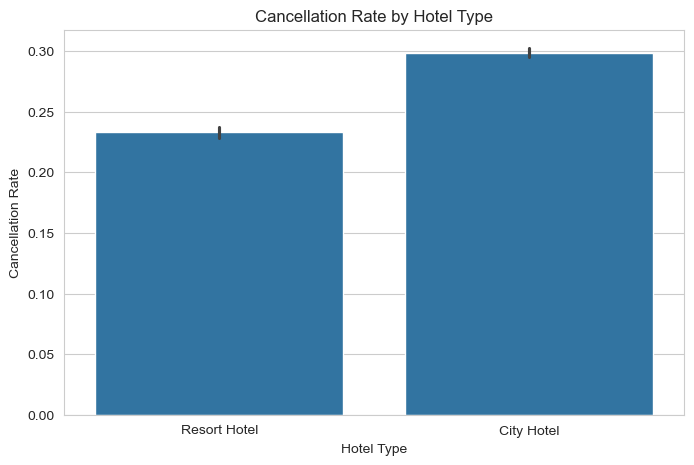

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_clean,
    x="hotel",
    y="is_canceled"
)
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate")
plt.show()

## Cancellation Rate by Hotel Type

Cancellation rates were compared between City Hotels and Resort Hotels.

City Hotels have a higher cancellation rate (approximately 29.9%) compared with Resort Hotels (approximately 23.3%).

This suggests that hotel type may be an important predictor of cancellation behavior.

In [43]:
segment_cancellation = pd.crosstab(
    df_clean["market_segment"],
    df_clean["is_canceled"],
    normalize="index"
) * 100

display(segment_cancellation)

is_canceled,0,1
market_segment,,
Aviation,80.088496,19.911504
Complementary,87.716763,12.283237
Corporate,88.090692,11.909308
Direct,85.319854,14.680146
Groups,74.106958,25.893042
Offline TA/TO,85.430847,14.569153
Online TA,64.760775,35.239225
Undefined,0.000000,100.000000


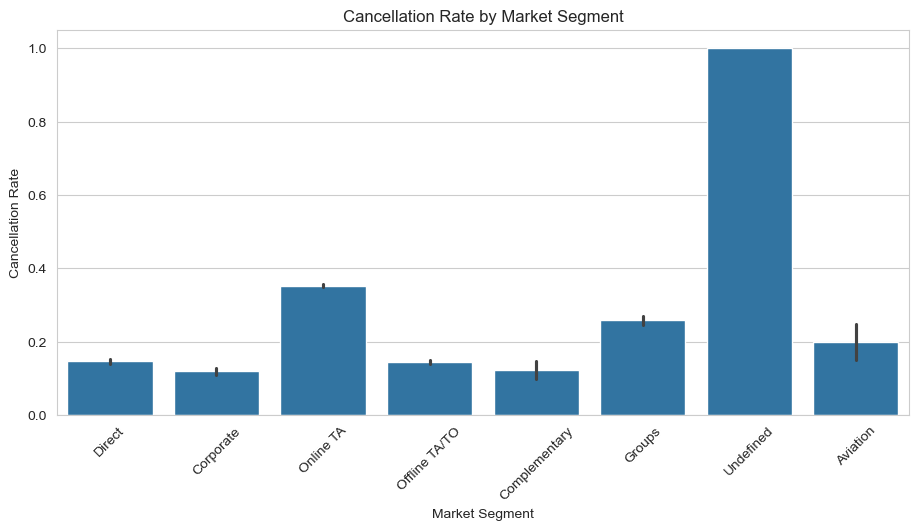

In [44]:
plt.figure(figsize=(11, 5))
sns.barplot(
    data=df_clean,
    x="market_segment",
    y="is_canceled"
)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

## Cancellation Rate by Market Segment

Cancellation behavior varies considerably across market segments.

Online Travel Agency (Online TA) bookings have one of the highest cancellation rates at approximately 35.2%, while Corporate and Direct bookings have substantially lower cancellation rates.

This indicates that the booking channel may be an important factor in predicting cancellation risk.

The Undefined category showing 100% cancellation should not automatically be interpreted as a strong business pattern because it may contain very few records.

In [45]:
deposit_cancellation = pd.crosstab(
    df_clean["deposit_type"],
    df_clean["is_canceled"],
    normalize="index"
) * 100

display(deposit_cancellation)

is_canceled,0,1
deposit_type,,
No Deposit,73.484222,26.515778
Non Refund,5.408063,94.591937
Refundable,75.700935,24.299065


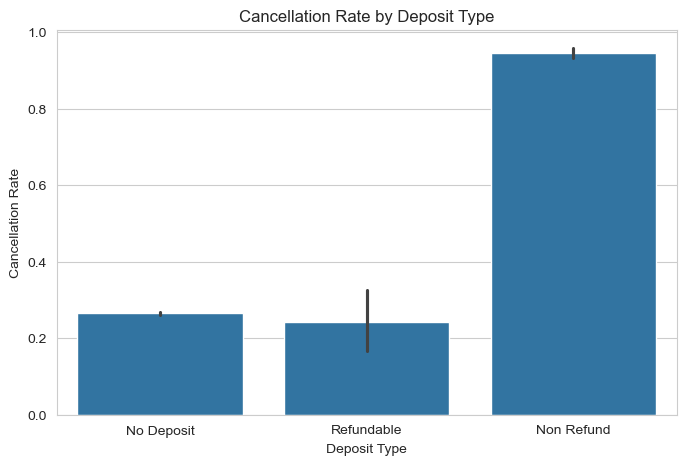

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_clean,
    x="deposit_type",
    y="is_canceled"
)
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")
plt.show()

## Cancellation Rate by Deposit Type

Deposit type shows a very strong relationship with booking cancellation.

Bookings classified as Non Refund have a cancellation rate of approximately 94.6%, compared with approximately 26.5% for No Deposit bookings.

This makes deposit type a potentially important predictive feature.

The unusually high cancellation rate for Non Refund bookings should also be investigated carefully to ensure that it is not caused by a data collection or business-rule artifact.

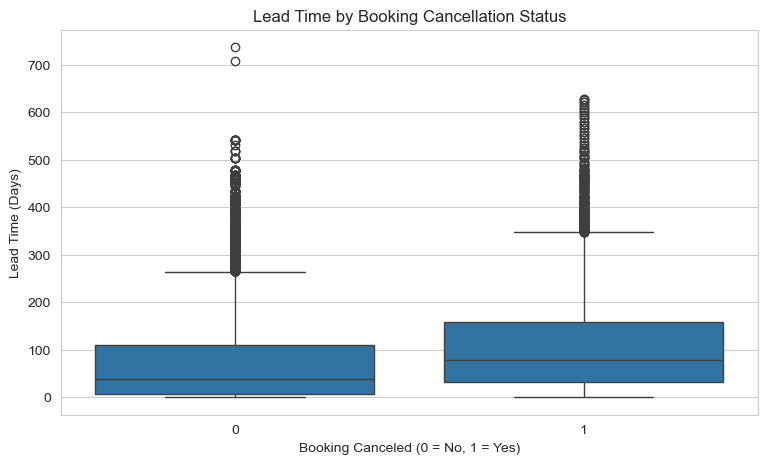

In [47]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="is_canceled",
    y="lead_time"
)
plt.title("Lead Time by Booking Cancellation Status")
plt.xlabel("Booking Canceled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time (Days)")
plt.show()

## Lead Time and Cancellation

The boxplot shows that canceled bookings generally have higher lead times than non-canceled bookings.

The correlation between lead time and cancellation is approximately 0.18, indicating a positive but relatively weak relationship.

This suggests that longer booking lead times may increase cancellation risk, although lead time alone is not sufficient to explain cancellation behavior.

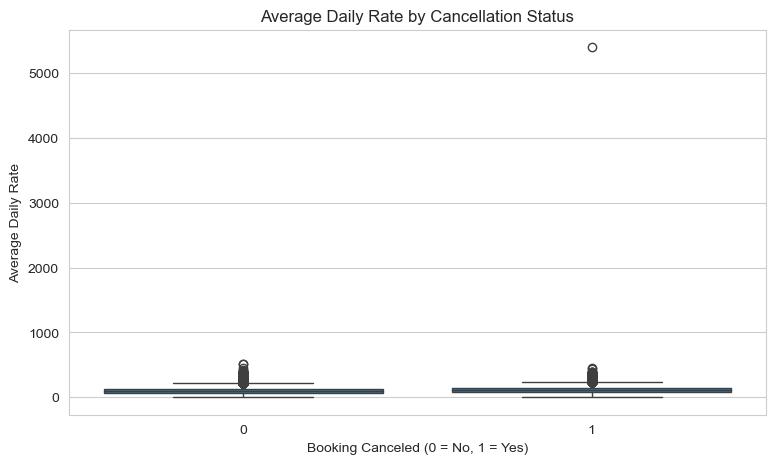

In [48]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df_clean,
    x="is_canceled",
    y="adr"
)
plt.title("Average Daily Rate by Cancellation Status")
plt.xlabel("Booking Canceled (0 = No, 1 = Yes)")
plt.ylabel("Average Daily Rate")
plt.show()

## Average Daily Rate and Cancellation

The distribution of Average Daily Rate (ADR) contains several extreme values.

Most observations are concentrated within a much smaller range, while a small number of bookings have unusually high ADR values.

These observations will be investigated during preprocessing and feature engineering before model training.

In [49]:
request_cancellation = pd.crosstab(
    df_clean["total_of_special_requests"],
    df_clean["is_canceled"],
    normalize="index"
) * 100

display(request_cancellation)

is_canceled,0,1
total_of_special_requests,,
0,67.072863,32.927137
1,77.628489,22.371511
2,78.817734,21.182266
3,82.886776,17.113224
4,89.375000,10.625000
5,94.444444,5.555556


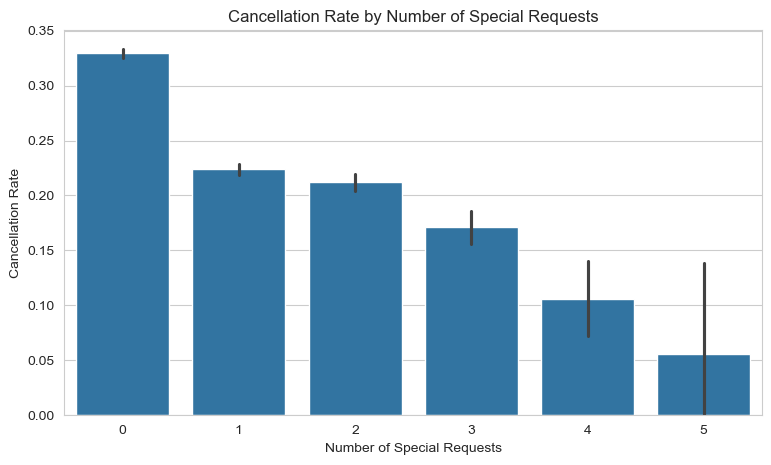

In [50]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_clean,
    x="total_of_special_requests",
    y="is_canceled"
)
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate")
plt.show()

## Cancellation Rate by Number of Special Requests

Cancellation rates decrease as the number of special requests increases.

Bookings with no special requests have a cancellation rate of approximately 32.9%, while bookings with five special requests have a cancellation rate of approximately 5.6%.

This suggests that customers who actively engage with the hotel and make additional requests may be more committed to completing their stay.

## Multivariate Analysis

Multivariate analysis examines relationships among multiple variables at the
same time.

A correlation heatmap is used to identify relationships between numerical
features and detect highly correlated variables.

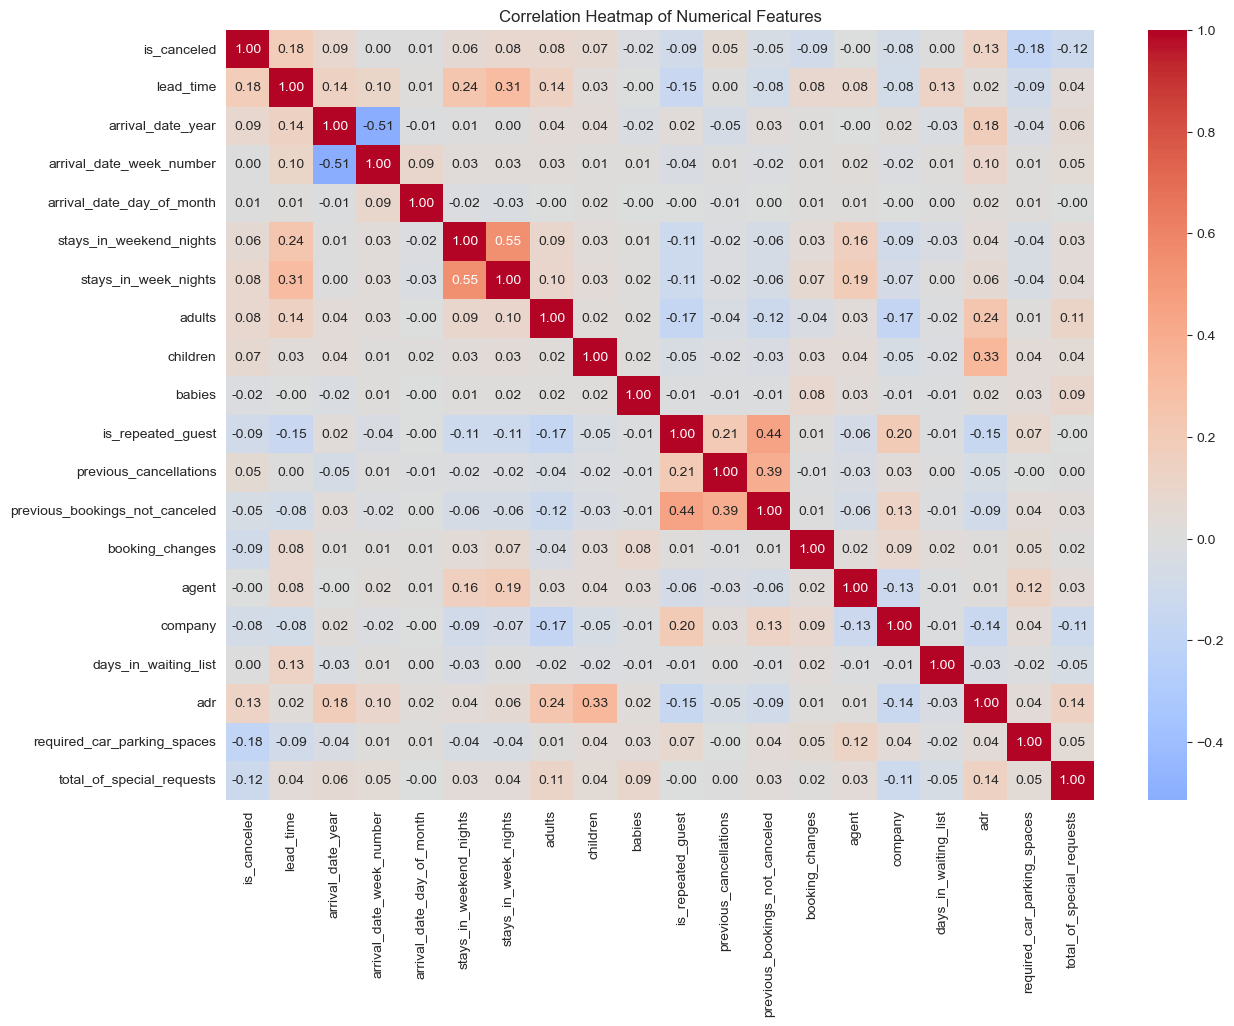

In [51]:
correlation_matrix = df_clean.select_dtypes(
    include=np.number
).corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Correlation Analysis

A correlation heatmap was used to examine relationships between numerical variables.

Lead time has a positive correlation with cancellation, while the number of special requests has a negative correlation with cancellation.

Several booking-related variables are also correlated with one another, such as weekend and weekday stay nights.

Correlation does not imply causation, but these relationships help identify potentially useful predictors for the Machine Learning models.

In [52]:
customer_cancellation = pd.crosstab(
    df_clean["customer_type"],
    df_clean["is_canceled"],
    normalize="index"
) * 100

display(customer_cancellation)

is_canceled,0,1
customer_type,,
Contract,83.694959,16.305041
Group,90.203327,9.796673
Transient,69.984108,30.015892
Transient-Party,85.679696,14.320304


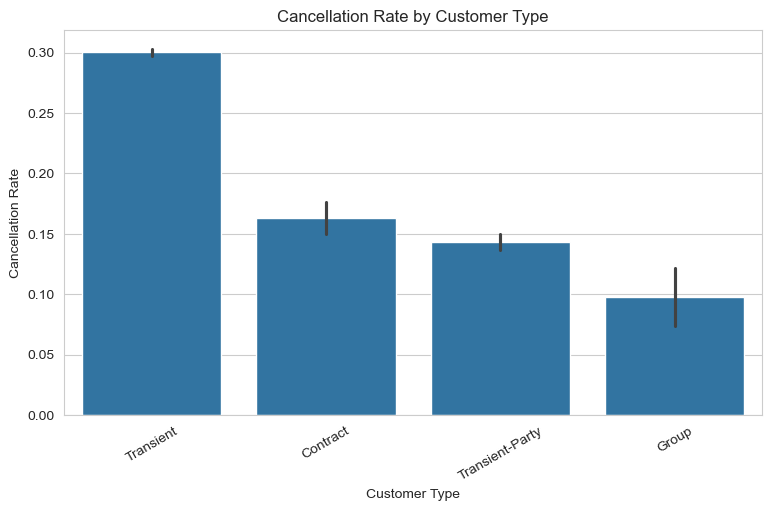

In [53]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_clean,
    x="customer_type",
    y="is_canceled"
)
plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=30)
plt.show()

## Cancellation Rate by Customer Type

Transient customers have the highest cancellation rate at approximately 30.0%.

Contract and Group customers have considerably lower cancellation rates.

This suggests that customer relationship type may provide useful information for cancellation prediction.

In [54]:
repeat_cancellation = pd.crosstab(
    df_clean["is_repeated_guest"],
    df_clean["is_canceled"],
    normalize="index"
) * 100

display(repeat_cancellation)

is_canceled,0,1
is_repeated_guest,,
0,71.902546,28.097454
1,92.296252,7.703748


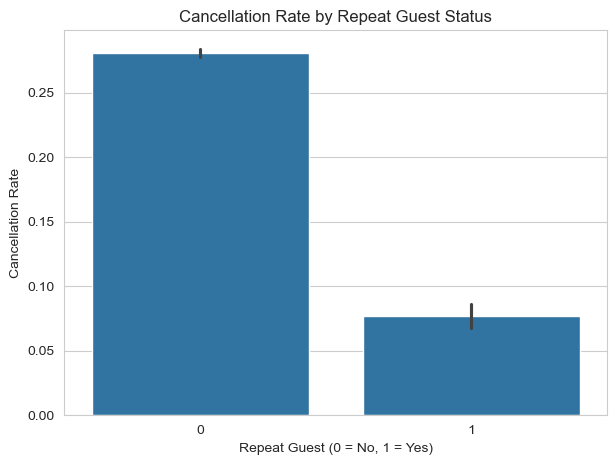

In [55]:
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df_clean,
    x="is_repeated_guest",
    y="is_canceled"
)
plt.title("Cancellation Rate by Repeat Guest Status")
plt.xlabel("Repeat Guest (0 = No, 1 = Yes)")
plt.ylabel("Cancellation Rate")
plt.show()

## Cancellation Rate by Repeat Guest Status

Repeat guests have a substantially lower cancellation rate than first-time guests.

Approximately 7.7% of repeat-guest bookings were canceled compared with approximately 28.1% of bookings from non-repeat guests.

This suggests that customer loyalty and previous hotel experience may be associated with lower cancellation risk.

## EDA Summary and Key Findings

The exploratory analysis identified several patterns associated with booking cancellations:

- Approximately 27.3% of bookings were canceled, indicating class imbalance.
- City Hotels have a higher cancellation rate than Resort Hotels.
- Online Travel Agency bookings show relatively high cancellation rates.
- Deposit type shows a particularly strong relationship with cancellation.
- Transient customers have higher cancellation rates than Contract and Group customers.
- Repeat guests have substantially lower cancellation rates than non-repeat guests.
- Bookings with longer lead times tend to have higher cancellation rates.
- Customers making more special requests tend to have lower cancellation rates.
- ADR contains extreme observations that require further investigation.
- Several numerical variables are correlated with each other, highlighting the importance of feature selection and leakage prevention.

These findings will guide the feature engineering and Machine Learning stages of the project.

# 7. Feature Engineering

Feature engineering involves creating new meaningful variables from existing features.

For the hotel cancellation problem, engineered features can help the models understand:

- Previous booking history
- Whether the reserved room was changed
- Whether the booking occurs on a weekend
- The customer's previous cancellation behavior

These features provide additional behavioral and booking-level information that may improve cancellation prediction.

In [56]:
df_clean["previous_cancellation_rate"] = np.where(
    (df_clean["previous_cancellations"] +
     df_clean["previous_bookings_not_canceled"]) > 0,
    df_clean["previous_cancellations"] /
    (
        df_clean["previous_cancellations"] +
        df_clean["previous_bookings_not_canceled"]
    ),
    0
)

df_clean[[
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "previous_cancellation_rate"
]].head()

,previous_cancellations,previous_bookings_not_canceled,previous_cancellation_rate
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0


### Why Create a Cancellation Rate?

The number of previous cancellations alone does not tell the complete story.

For example:

- Customer A: 2 cancellations out of 2 bookings → 100%
- Customer B: 2 cancellations out of 10 bookings → 20%

Both have 2 previous cancellations, but their behavior is very different.

The cancellation rate captures this difference.

In [57]:
df_clean["room_changed"] = (
    df_clean["reserved_room_type"] !=
    df_clean["assigned_room_type"]
).astype(int)

df_clean[[
    "reserved_room_type",
    "assigned_room_type",
    "room_changed"
]].head()

,reserved_room_type,assigned_room_type,room_changed
0,C,C,0
1,C,C,0
2,A,C,1
3,A,A,0
4,A,A,0


In [58]:
df_clean["has_weekend_stay"] = (
    df_clean["stays_in_weekend_nights"] > 0
).astype(int)

df_clean[[
    "stays_in_weekend_nights",
    "has_weekend_stay"
]].head()

,stays_in_weekend_nights,has_weekend_stay
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [59]:
df_clean["is_group_booking"] = (
    (
        df_clean["adults"] +
        df_clean["children"] +
        df_clean["babies"]
    ) > 2
).astype(int)

df_clean[[
    "adults",
    "children",
    "babies",
    "is_group_booking"
]].head()

,adults,children,babies,is_group_booking
0,2,0.0,0,0
1,2,0.0,0,0
2,1,0.0,0,0
3,1,0.0,0,0
4,2,0.0,0,0


In [60]:
print("Dataset Shape:", df_clean.shape)

Dataset Shape: (86971, 34)


In [61]:
print("Original columns:", len(df.columns))
print("Current columns:", len(df_clean.columns))

print("\nNew columns:")
print([col for col in df_clean.columns if col not in df.columns])

Original columns: 30
Current columns: 34

New columns:
['previous_cancellation_rate', 'room_changed', 'has_weekend_stay', 'is_group_booking']


# 8. Data Leakage Prevention

Data leakage occurs when information that would not realistically be available at prediction time is used by the model.

For this project, the goal is to predict whether a hotel booking will be cancelled.

Therefore, we must remove features that are only known **after the cancellation outcome or after the booking process has progressed**, because they could allow the model to "cheat".

Leakage prevention is important because a model with leaked information may achieve unrealistically high performance but fail in real-world use.

In [62]:
leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

existing_leakage_columns = [
    col for col in leakage_columns
    if col in df_clean.columns
]

if existing_leakage_columns:
    df_clean.drop(columns=existing_leakage_columns, inplace=True)
    print("Leakage-prone columns removed:", existing_leakage_columns)
else:
    print("Leakage-prone columns are already removed.")

Leakage-prone columns are already removed.


## 9. Feature Selection

Feature selection involves identifying the variables that will be used as
input features for the machine learning models.

The target variable for this project is `is_canceled`, which indicates
whether a hotel booking was cancelled:

- 0 = Not cancelled
- 1 = Cancelled

The target variable must be separated from the predictor variables to
prevent the model from using the answer itself as an input.

At this stage, we will also remove features that are not suitable as
predictors while retaining variables that may contain useful information
about the customer's booking behavior, booking characteristics, and
cancellation history.

In [63]:
target = "is_canceled"
# separate features and target
X = df_clean.drop(columns=[target])
y = df_clean[target]
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (86971, 33)
Target shape: (86971,)


## 10. Encoding & Scaling

Machine learning models require numerical input, so categorical features
must be converted into numerical values.

We will use one-hot encoding for categorical variables and standard scaling
for numerical variables.

In [64]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

Categorical columns: 10
Numerical columns: 23


In [65]:
print("Categorical:", list(categorical_cols))
print("\nNumerical:", list(numerical_cols))

Categorical: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Numerical: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'previous_cancellation_rate', 'room_changed', 'has_weekend_stay', 'is_group_booking']


### Encoding and Scaling

Categorical variables will be converted using One-Hot Encoding.

Numerical variables will be standardized using StandardScaler so that
features with different numerical ranges are placed on a comparable scale.

In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


## 11. Train/Test Split

The dataset is divided into training and testing sets.

The training set will be used to train the models, while the testing set
will be used to evaluate their performance on unseen data.

In [67]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (69576, 33)
Testing set: (17395, 33)


In [68]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (69576, 256)
Processed testing shape: (17395, 256)


### Encoding and Scaling Result

The categorical variables have been one-hot encoded and the numerical
variables have been standardized.

The preprocessor was fitted only on the training data and then applied
to the testing data to prevent data leakage.

## 12. Class Imbalance Handling

Class imbalance occurs when one target class has significantly more
observations than another.

Since cancellation prediction has more non-cancelled bookings than
cancelled bookings, we will handle the class distribution before training
the models.

In [69]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True) * 100)

Training target distribution:
is_canceled
0    50575
1    19001
Name: count, dtype: int64

Training target percentage:
is_canceled
0    72.690296
1    27.309704
Name: proportion, dtype: float64


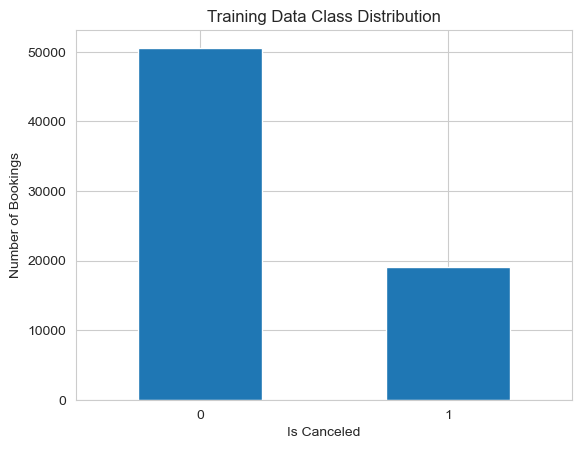

In [70]:
y_train.value_counts().plot(kind="bar")

plt.title("Training Data Class Distribution")
plt.xlabel("Is Canceled")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.show()

## 13. Multiple ML Models

Multiple machine learning algorithms will be trained and compared to
determine which model performs best for hotel booking cancellation
prediction.

The models selected are Logistic Regression, Decision Tree, and Random
Forest.

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    print(name, "trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [73]:
from xgboost import XGBClassifier

models["XGBoost"] = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

models["XGBoost"].fit(X_train_processed, y_train)
print("XGBoost trained successfully.")

XGBoost trained successfully.


## 14. Hyperparameter Tuning

Hyperparameters are settings chosen before training a machine learning
model. Hyperparameter tuning tests different combinations of these
settings to find a configuration that improves model performance.

In [74]:
from sklearn.model_selection import GridSearchCV

### Random Forest Tuning

The Random Forest hyperparameters we will tune are the number of trees,
maximum tree depth, and minimum samples required to split a node.

In [77]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
rf_grid.fit(X_train_processed, y_train)
print("Best Random Forest parameters:", rf_grid.best_params_)

Best Random Forest parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


### XGBoost Tuning

For XGBoost, we tune the number of trees, learning rate, and maximum tree
depth.

In [78]:
xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 6]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train_processed, y_train)

print("Best XGBoost parameters:", xgb_grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


## 15. Model Evaluation

The trained models are evaluated using multiple classification metrics.

Accuracy measures overall correctness, while Precision and Recall focus
on the cancellation class. F1-score balances Precision and Recall.

ROC-AUC measures the model's ability to distinguish between the two classes,
while PR-AUC provides additional insight into performance on the minority
class.

In [80]:
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

In [81]:
final_models = {
    "Logistic Regression": models["Logistic Regression"],
    "Decision Tree": models["Decision Tree"],
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

In [82]:
results = []

for name, model in final_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

In [83]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,XGBoost,0.851911,0.758810,0.670947,0.712179,0.916825,0.805349
1,Random Forest,0.803737,0.598700,0.853053,0.703594,0.902853,0.781361
2,Decision Tree,0.804714,0.641261,0.646526,0.643883,0.755810,0.512742
3,Logistic Regression,0.755217,0.534904,0.793684,0.639091,0.850358,0.688207


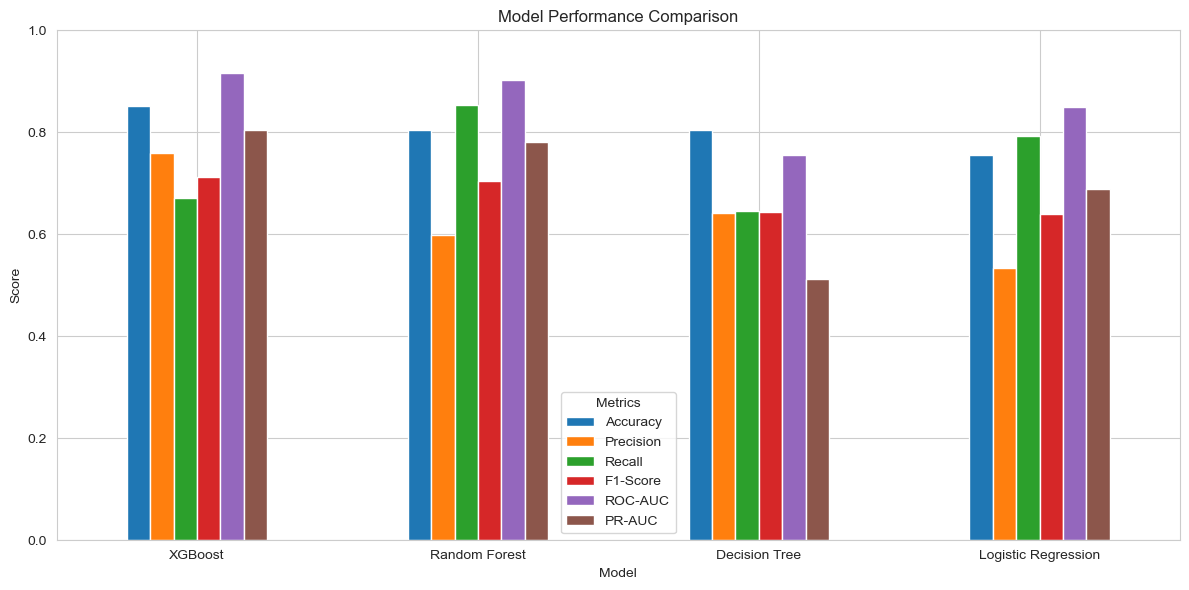

In [84]:
import matplotlib.pyplot as plt
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]
results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

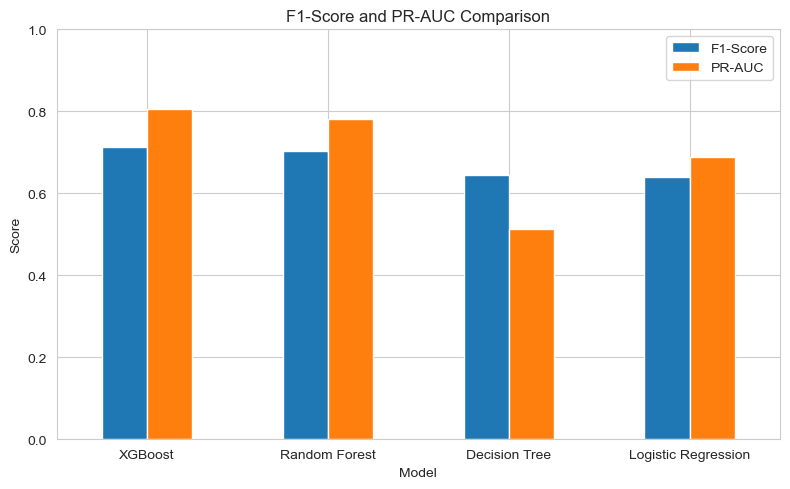

In [85]:
results_df.set_index("Model")[["F1-Score", "PR-AUC"]].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("F1-Score and PR-AUC Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Evaluation Results

XGBoost achieved the strongest overall performance, obtaining the highest
Accuracy, Precision, F1-Score, ROC-AUC, and PR-AUC.

Random Forest achieved the highest Recall, meaning it identified the largest
proportion of actual cancelled bookings.

Since the goal is to predict cancellations while maintaining a balance
between Precision and Recall, XGBoost provides the strongest overall
performance among the evaluated models.

## 16. Threshold Analysis

Classification models use a probability threshold to convert predicted
probabilities into class predictions.

The default threshold is 0.5. By changing this threshold, we can control
the trade-off between Precision and Recall.

A lower threshold generally increases Recall, while a higher threshold
generally increases Precision.

In [86]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
best_model = best_xgb
y_prob = best_model.predict_proba(X_test_processed)[:, 1]
thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []
for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-Score": f1_score(y_test, y_pred_threshold)
    })
threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.1,0.478773,0.975789,0.642367
1,0.2,0.563918,0.921263,0.699600
2,0.3,0.642279,0.852000,0.732422
3,0.4,0.706019,0.765474,0.734545
4,0.5,0.758810,0.670947,0.712179
5,0.6,0.798920,0.560421,0.658748
6,0.7,0.852916,0.418737,0.561706
7,0.8,0.923606,0.254526,0.399076
8,0.9,0.981605,0.123579,0.219521


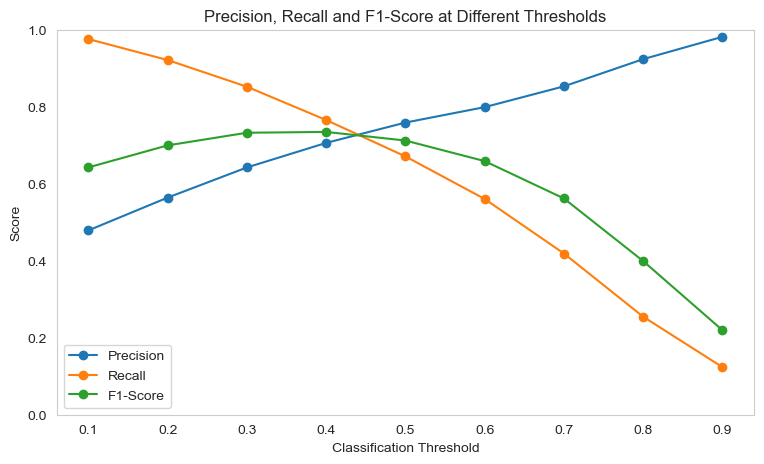

In [87]:
plt.figure(figsize=(9, 5))
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)
plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score at Different Thresholds")
plt.ylim(0, 1)
plt.legend()
plt.grid()
plt.show()

In [88]:
best_threshold = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]
print("Best threshold based on F1-Score:")
print(best_threshold)

Best threshold based on F1-Score:
Threshold    0.400000
Precision    0.706019
Recall       0.765474
F1-Score     0.734545
Name: 3, dtype: float64


### Threshold Analysis Result

The default classification threshold of 0.5 produced an F1-score of 0.712.

The highest F1-score was achieved at a threshold of 0.4, with a Precision
of 0.706 and Recall of 0.765.

Therefore, a threshold of 0.4 provides the best balance between Precision
and Recall for the XGBoost model and will be considered the selected
threshold for the final prediction analysis.

## 17. Feature Importance

Feature importance shows which input variables contribute most to the
model's predictions.

The feature importance values from the tuned XGBoost model will be used
to identify the factors that have the greatest influence on booking
cancellation predictions.

In [89]:
feature_names = preprocessor.get_feature_names_out()
importance = best_xgb.feature_importances_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)
feature_importance.head(15)

,Feature,Importance
20,num__room_changed,0.185699
17,num__required_car_parking_spaces,0.093729
222,cat__market_segment_Online TA,0.089102
175,cat__country_PRT,0.051944
18,num__total_of_special_requests,0.033126
219,cat__market_segment_Direct,0.030949
250,cat__deposit_type_Non Refund,0.029444
254,cat__customer_type_Transient,0.025516
249,cat__deposit_type_No Deposit,0.024624
19,num__previous_cancellation_rate,0.020468


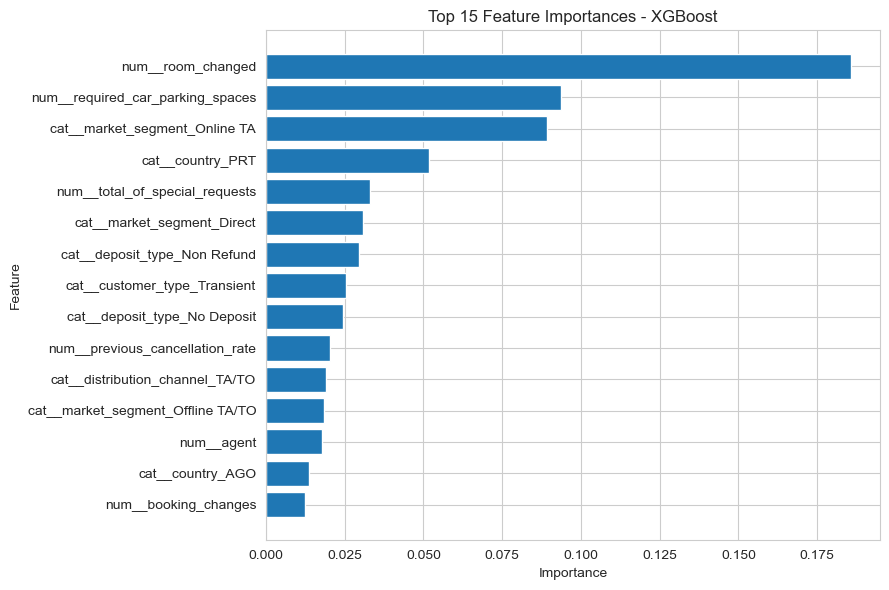

In [90]:
top_features = feature_importance.head(15).sort_values("Importance")
plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 18. Business Impact Analysis

The selected probability threshold of **0.4** is applied to the final XGBoost model to evaluate its practical business impact.

Instead of using the default threshold of 0.5, a threshold of 0.4 allows the model to identify more bookings that are at risk of cancellation. This is useful for a hotel because identifying potential cancellations in advance can allow management to take proactive actions such as contacting customers, confirming bookings, or adjusting room allocation and overbooking decisions.

The analysis focuses on:
- The number of bookings predicted as cancellations.
- The number of actual cancellations correctly identified.
- The number of cancellations missed by the model.
- The number of bookings incorrectly flagged as cancellations.
- The overall practicality of using the model for proactive cancellation management.

In [93]:
# Apply the selected 0.4 threshold
y_pred_04 = (y_prob >= 0.4).astype(int)
print("Predictions using 0.4 threshold:")
print(pd.Series(y_pred_04).value_counts())

Predictions using 0.4 threshold:
0    12245
1     5150
Name: count, dtype: int64


In [94]:
from sklearn.metrics import confusion_matrix
# Generate confusion matrix using the 0.4 threshold
cm_04 = confusion_matrix(y_test, y_pred_04)
tn, fp, fn, tp = cm_04.ravel()
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 11131
False Positives: 1514
False Negatives: 1114
True Positives  : 3636


In [95]:
# Cancellation Detection Rate (Recall)
cancellation_detection_rate = tp / (tp + fn)
# Percentage of all bookings flagged as potential cancellations
flagged_booking_rate = (tp + fp) / len(y_test)
# False alarm rate among non-cancelled bookings
false_alarm_rate = fp / (fp + tn)
print(f"Cancellation Detection Rate: {cancellation_detection_rate:.2%}")
print(f"Bookings Flagged for Intervention: {flagged_booking_rate:.2%}")
print(f"False Alarm Rate: {false_alarm_rate:.2%}")

Cancellation Detection Rate: 76.55%
Bookings Flagged for Intervention: 29.61%
False Alarm Rate: 11.97%


In [96]:
business_impact = pd.DataFrame({
    "Metric": [
        "Total Test Bookings",
        "Actual Cancellations",
        "Actual Non-Cancellations",
        "Predicted Cancellations",
        "Correctly Identified Cancellations",
        "Missed Cancellations",
        "False Cancellation Predictions"
    ],
    "Count": [
        len(y_test),
        tp + fn,
        tn + fp,
        tp + fp,
        tp,
        fn,
        fp
    ]
})
business_impact

,Metric,Count
0,Total Test Bookings,17395
1,Actual Cancellations,4750
2,Actual Non-Cancellations,12645
3,Predicted Cancellations,5150
4,Correctly Identified Cancellations,3636
5,Missed Cancellations,1114
6,False Cancellation Predictions,1514


In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_04 = accuracy_score(y_test, y_pred_04)
precision_04 = precision_score(y_test, y_pred_04)
recall_04 = recall_score(y_test, y_pred_04)
f1_04 = f1_score(y_test, y_pred_04)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy_04:.4f}")
print(f"Precision: {precision_04:.4f}")
print(f"Recall   : {recall_04:.4f}")
print(f"F1-Score: {f1_04:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8489
Precision: 0.7060
Recall   : 0.7655
F1-Score: 0.7345
ROC-AUC  : 0.9168


## 19. Business Recommendations

Based on the model comparison, feature importance analysis, and business impact analysis, **XGBoost was selected as the final classification model**. At the default 0.5 threshold, XGBoost achieved the highest overall performance among the tested models, including an **Accuracy of 85.19%, ROC-AUC of 91.68%, and PR-AUC of 80.53%**. Random Forest achieved higher cancellation Recall, but XGBoost provided a stronger overall balance of performance.

For operational use, a **0.4 probability threshold** was selected for XGBoost to identify more potential cancellations. At this threshold, the model achieved **84.89% Accuracy, 70.60% Precision, 76.55% Recall, 73.45% F1-Score, and 91.68% ROC-AUC**. It correctly identified **3,636 of 4,750 actual cancellations**, while flagging 5,150 bookings for potential intervention.

The hotel can use these predictions as a decision-support system by:

- Flagging bookings with a predicted cancellation probability of 0.4 or higher.
- Prioritizing high-risk bookings for confirmation or reminder communication.
- Monitoring influential booking characteristics such as room changes, market segment, required parking spaces, country, special requests, deposit type, and previous cancellation behavior.
- Using cancellation-risk predictions to support room inventory and occupancy planning.
- Combining model predictions with human judgment rather than automatically cancelling or modifying reservations.

The model identifies patterns associated with cancellations, but feature importance does not prove that a feature directly causes cancellation. Similarly, the dataset does not measure the success of interventions, so the model's financial impact should be evaluated after deployment using real business outcomes.

## 20. Final Conclusion

This project developed machine learning models to predict hotel booking cancellations and identify factors associated with cancellation behavior. The dataset was explored, cleaned, preprocessed, and transformed through feature engineering before training and evaluating multiple classification models.

Four classification models were compared: **XGBoost, Random Forest, Decision Tree, and Logistic Regression**. XGBoost provided the strongest overall performance, achieving **85.19% Accuracy, 75.88% Precision, 67.09% Recall, 71.22% F1-Score, 91.68% ROC-AUC, and 80.53% PR-AUC** at the default 0.5 threshold.

Threshold analysis showed that **0.4** provides a useful operating point when the priority is to detect more potential cancellations. At this threshold, XGBoost detected **76.55% of actual cancellations** and correctly identified **3,636 cancellations** in the test set.

Feature importance analysis showed that **room changes (`room_changed`)** was the most influential feature, followed by required parking spaces, Online Travel Agent market segment, country, special requests, direct market segment, deposit type, and previous cancellation rate.

Overall, the developed model can serve as a **decision-support tool for proactive hotel cancellation management**. By identifying higher-risk bookings in advance, hotels can focus customer communication, reservation monitoring, and inventory planning efforts where they are most needed. Future improvements could include testing additional models and features, performing more detailed hyperparameter optimization, monitoring model performance on new booking data, and evaluating the actual financial benefits of interventions.